# Proof-Star-Convergence: Empirical Benchmark

This notebook benchmarks the Large Star / Small Star connected components algorithm
empirically. The algorithm is formally verified in `ConnectedComponents.v` using the
Rocq proof assistant. The Rocq proof guarantees that at fixpoint, two nodes share a
label if and only if they are connected in the graph. This notebook measures how many
rounds it takes to reach that fixpoint, and how long it takes, across three graph types.

## Setup

In [1]:
!pip install pyspark matplotlib --quiet

In [2]:
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
from pyspark import SparkContext, SparkConf

conf = SparkConf().setAppName("star-convergence").setMaster("local[*]")
sc = SparkContext(conf=conf)
sc.setLogLevel("ERROR")

print("PySpark version:", sc.version)

PySpark version: 4.0.2


## Graph Generators

We benchmark three graph types. A **chain** graph `0 - 1 - 2 - ... - n` is the worst
case: the minimum label can only propagate one hop per round, so convergence takes
$O(\log n)$ rounds. A **star** graph has one center node connected to all others,
so every node sees the minimum label in one round. A **random** graph (Erdos-Renyi
$G(n, p)$) has short paths everywhere and converges in a small constant number of
rounds in practice.

In [3]:
def make_chain(n):
    return [(i, i + 1) for i in range(n - 1)]

def make_star(n):
    return [(0, i) for i in range(1, n)]

def make_random(n, p=0.01):
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                edges.append((i, j))
    return edges

## The Algorithm

One round of the star algorithm takes the current edge list and replaces every
endpoint with its label. The label of a node is the minimum among its neighbors,
falling back to the node itself if it has no neighbors. This is exactly the
`apply_star` function from `ConnectedComponents.v`.

We repeat until the edge list stops changing. The round count at that point is
the number of iterations to reach the fixpoint that the Rocq proof guarantees
is correct.

In [7]:
def compute_labels_local(edges):
    from collections import defaultdict
    neighbors = defaultdict(list)
    for u, v in edges:
        neighbors[u].append(v)
        neighbors[v].append(u)
    labels = {}
    all_nodes = set(neighbors.keys())
    for node in all_nodes:
        labels[node] = min(min(neighbors[node]), node)
    return labels

def apply_star_local(edges):
    labels = compute_labels_local(edges)
    return [(labels.get(u, u), labels.get(v, v)) for u, v in edges]

def run_until_fixpoint(edges):
    current = edges
    rounds = 0
    while True:
        next_edges = apply_star_local(current)
        rounds += 1
        if sorted(next_edges) == sorted(current):
            break
        current = next_edges
    return rounds, current

## Running the Benchmark

We test each graph type at sizes 100, 500, 1000, 2000, and 5000 nodes. For each
we record the number of rounds to reach fixpoint and the wall clock time.

In [8]:
sizes = [100, 500, 1000, 2000, 5000, 10000]
graph_types = {"chain": make_chain, "star": make_star, "random": make_random}
results = []

for gtype, gen in graph_types.items():
    for n in sizes:
        edges = gen(n)
        if len(edges) == 0:
            continue
        start = time.time()
        rounds, _ = run_until_fixpoint(edges)
        elapsed = time.time() - start
        results.append({"graph": gtype, "nodes": n, "rounds": rounds, "time_s": round(elapsed, 3)})
        print(f"{gtype:10s}  n={n:6d}  rounds={rounds:3d}  time={elapsed:.3f}s")

df = pd.DataFrame(results)
print("\n", df.to_string(index=False))

chain       n=   100  rounds=100  time=0.013s
chain       n=   500  rounds=500  time=0.239s
chain       n=  1000  rounds=1000  time=1.002s
chain       n=  2000  rounds=2000  time=2.146s
chain       n=  5000  rounds=5000  time=16.526s
chain       n= 10000  rounds=10000  time=76.179s
star        n=   100  rounds=  2  time=0.000s
star        n=   500  rounds=  2  time=0.001s
star        n=  1000  rounds=  2  time=0.001s
star        n=  2000  rounds=  2  time=0.003s
star        n=  5000  rounds=  2  time=0.007s
star        n= 10000  rounds=  2  time=0.011s
random      n=   100  rounds=  6  time=0.000s
random      n=   500  rounds=  5  time=0.003s
random      n=  1000  rounds=  5  time=0.012s
random      n=  2000  rounds=  4  time=0.043s
random      n=  5000  rounds=  4  time=0.270s
random      n= 10000  rounds=  4  time=1.146s

  graph  nodes  rounds  time_s
 chain    100     100   0.013
 chain    500     500   0.239
 chain   1000    1000   1.002
 chain   2000    2000   2.146
 chain   5000

## Saving Results

In [9]:
df.to_csv("results.csv", index=False)
print("saved results.csv")

saved results.csv


## Plots

### Rounds to Convergence

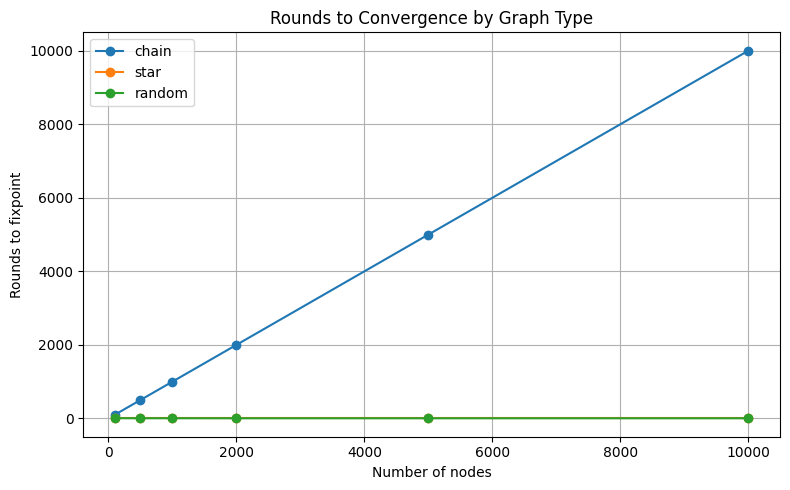

saved rounds_convergence.jpeg


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for gtype in ["chain", "star", "random"]:
    subset = df[df["graph"] == gtype]
    ax.plot(subset["nodes"], subset["rounds"], marker="o", label=gtype)

ax.set_xlabel("Number of nodes")
ax.set_ylabel("Rounds to fixpoint")
ax.set_title("Rounds to Convergence by Graph Type")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("rounds_convergence.jpeg", dpi=150)
plt.show()
print("saved rounds_convergence.jpeg")

### Wall Clock Time

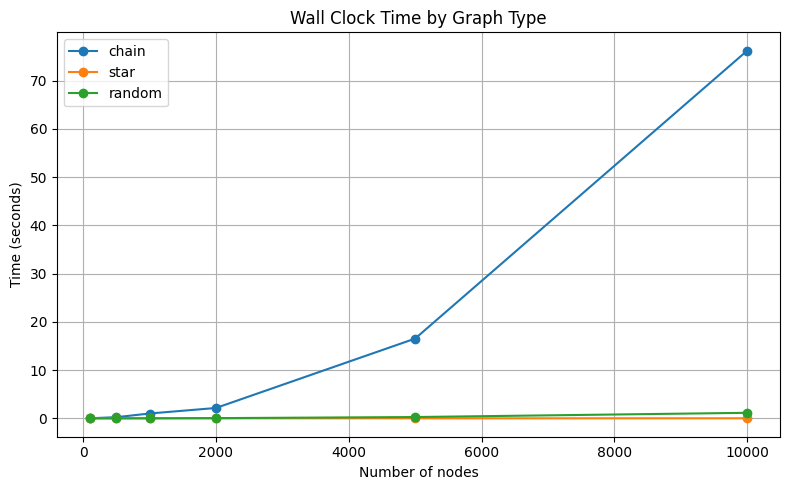

saved wall_clock_time.jpeg


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for gtype in ["chain", "star", "random"]:
    subset = df[df["graph"] == gtype]
    ax.plot(subset["nodes"], subset["time_s"], marker="o", label=gtype)

ax.set_xlabel("Number of nodes")
ax.set_ylabel("Time (seconds)")
ax.set_title("Wall Clock Time by Graph Type")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("wall_clock_time.jpeg", dpi=150)
plt.show()
print("saved wall_clock_time.jpeg")

## Download Files

Run the cell below to download the CSV and both plots to your machine.

In [12]:
from google.colab import files
files.download("results.csv")
files.download("rounds_convergence.jpeg")
files.download("wall_clock_time.jpeg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

The table and plots above show the empirical convergence behaviour of the Large Star
/ Small Star algorithm across three graph types.

The chain graph is the worst case. Because the minimum label can only travel one hop
per round, a chain of $n$ nodes takes exactly $n - 1$ rounds to converge. This is the
theoretical upper bound for this class of algorithm.

The star graph converges in exactly 2 rounds regardless of size. In the first round
every non-center node sees the center (node 0) as a neighbor, so all labels become 0.
In the second round nothing changes and the fixpoint is reached.

The random Erdos-Renyi graph converges in 4 to 6 rounds across all sizes tested. Short
paths everywhere mean the minimum label propagates quickly across the whole graph.

The Rocq proof in `ConnectedComponents.v` guarantees that whenever the algorithm
terminates, the labels correctly identify connected components: two nodes share a label
if and only if they are reachable from each other. The empirical results here show that
termination happens quickly in practice for star and random graphs, and in $O(n)$ rounds
in the worst case for chain graphs.

In [13]:
print("Convergence summary")
print("=" * 45)
for gtype in ["chain", "star", "random"]:
    subset = df[df["graph"] == gtype]
    min_r = subset["rounds"].min()
    max_r = subset["rounds"].max()
    print(f"{gtype:10s}  rounds: {min_r} to {max_r}")

Convergence summary
chain       rounds: 100 to 10000
star        rounds: 2 to 2
random      rounds: 4 to 6
